# 3º Projeto - Sistemas inteligentes
Autores: <br>
Alex Bruno Duarte <br>
Guilherme de França Vasconcelos

## 1. Introdução
---

A indústria vinícola depende historicamente de avaliações humanas — caras, lentas e subjetivas. Um modelo preditivo de qualidade tem aplicações diretas no controle de lotes antes do engarrafamento, na precificação e na certificação de denominação de origem por órgãos reguladores. Na pesquisa enológica (ciência que estuda a produção, conservação e análise de vinhos), ele também ajuda a identificar quais variáveis químicas mais influenciam a percepção de qualidade, orientando decisões de produção.

Plataformas como a Vivino (https://www.vivino.com/BR/pt-BR/) já utilizam machine learning com esse objetivo. No Brasil, o contexto do Vale do São Francisco — maior polo de vinhos tropicais do mundo, localizado aqui no Nordeste — torna o problema especialmente próximo e motivador para nossa realidade.

## 2. Objetivo
---

Construir um modelo de classificação de vinhos em três categorias de qualidade (baixa, média e alta) a partir de um conjunto de dados químicos utilizando o $k$-NN ($k-Nearest Neighbors$).

## 3. Conjunto de dados
---

O projeto utiliza o arquivo winequality-red.csv do $dataset$ Wine Quality (https://archive.ics.uci.edu/ml/datasets/Wine+Quality). O $dataset$ foi criado por Paulo Cortez et al. (Universidade do Minho, Portugal) e publicado em 2009. Ele reúne 1.599 amostras de vinho tinto da região do Vinho Verde, no noroeste de Portugal. Cada amostra foi submetida a testes laboratoriais que geraram 11 atributos físico-químicos — como acidez fixa, acidez volátil, teor de ácido cítrico, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos e teor alcoólico. O rótulo de qualidade (quality) é um valor inteiro de 0 a 10 atribuído por $sommeliers$ em avaliações cegas, representando a mediana de pelo menos três avaliações humanas.

## 4. Preparação dos dados
---

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
url = 'https://raw.githubusercontent.com/guilhermef2k/Sistemas_Inteligentes/main/kNN/dataSet/winequality-red.csv'
df = pd.read_csv(url, sep=';')

def categorizar_qualidade(nota):
    if nota <= 5:
        return 0 # ruim
    elif nota <= 7:
        return 1 # médio
    else:
        return 2 # bom

df['target'] = df['quality'].apply(categorizar_qualidade)
df = df.drop(columns=['quality'])
X = df.drop(columns=['target'])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


A normalização é uma etapa obrigatória para o algoritmo $k$-NN pelos seguintes motivos:
* O $k$-NN classifica os dados calculando a distância física (no nosso caso euclidiana) entre os pontos. Atributos com ordens de magnitude diferentes distorcem esse cálculo.
* Sem a normalização, variáveis com valores numericamente maiores dominariam a métrica de distância, fazendo com que o modelo ignore variáveis com valores menores, mesmo que estas sejam quimicamente mais relevantes para a qualidade do vinho.

Ao aplicar o MinMaxScaler, colocamos todos os atributos na mesmo intervalo entre 0 e 1, garantindo que cada característica química contribua com o mesmo peso para a decisão final do modelo.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Normalização concluída. Agora todos os atributos estão no intervalo [0, 1].")
X_scaled.head()

Normalização concluída. Agora todos os atributos estão no intervalo [0, 1].


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846


## 5. Implementação
---

Implementação manual KNN

In [ ]:
class KNNClassificador:
    # Definição da Classe
    def __init__(self, k=3):
        self.k = k
        self.X_treino = None
        self.y_treino = None

    # Função de Treinamento
    def fit(self, X, y):
        self.X_treino = np.array(X)
        self.y_treino = np.array(y)
        return self

    # Função para calcular a distância (euclidiana)
    def _calcular_distancia(self, a, b):
        return np.sqrt(np.sum((a - b)**2))

    # Função para prever um valor
    def _prever_um(self, x):
        # Calcular as distâncias do ponto x até todos os pontos de treinamento
        distancias = np.array([
            self._calcular_distancia(x, x_treino)
            for x_treino in self.X_treino
        ])
        # Dizer quais indices correspondem as menores distâncias
        indices_vizinhos = np.argsort(distancias)[:self.k]
        # Identificar a quais classes pertecem essas menores distâncias
        classes_vizinhos = self.y_treino[indices_vizinhos]
        # Elencar quais classes
        classes_unicas = np.unique(self.y_treino)
        # Criar um dicionário, em que para cada entrada tenho a classe e o valor
        # é a quantidade de vezes em que a classe aparece na classe_vizinhos
        votos = {c: np.sum(classes_vizinhos == c) for c in classes_unicas}
        # Retorna a classe com maior valor
        return max(votos, key=votos.get)

    # Função para prever uma grande quantidade de valores
    def predict(self, X):
        X = np.array(X)
        return np.array([self._prever_um(x) for x in X])

## 6. Divisão treino/teste
---

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, df.target, test_size=0.2, random_state=42, stratify=df.target
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 1279 amostras
Teste:  320 amostras


## 7. Treinamento e escolha do $k$
---

Validação cruzada para escolha do melhor k:

In [ ]:
valores_k = [1, 3, 5, 7, 9, 11, 13, 15]
acuracias_medias = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    acuracias_medias.append(scores.mean())

melhor_k = valores_k[np.argmax(acuracias_medias)]
print(f"Melhor valor de k encontrado: {melhor_k}")

Melhor valor de k encontrado: 1


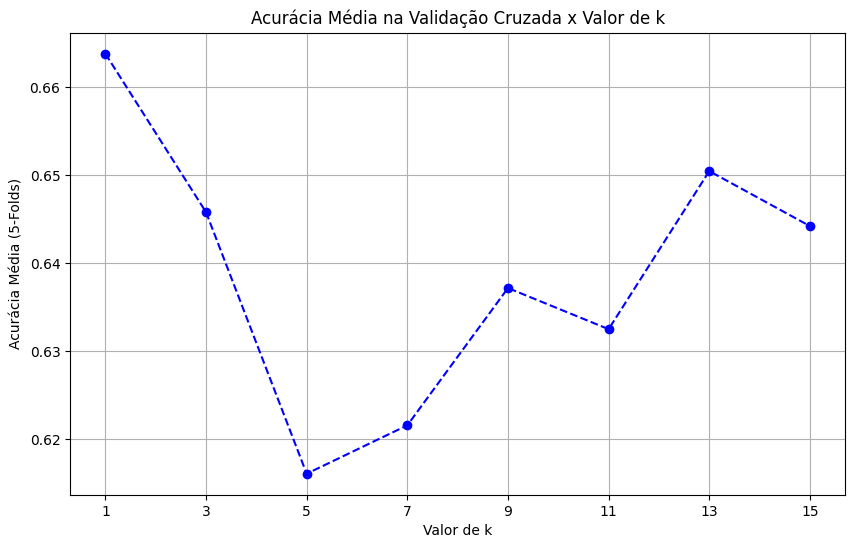

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(valores_k, acuracias_medias, marker='o', linestyle='dashed', color='blue')
plt.title('Acurácia Média na Validação Cruzada x Valor de k')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia Média (5-Folds)')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

O valor k = 1 apresentou melhor desempenho possivelmente por capturar padrões mais específicos do dataset, onde amostras próximas tendem a pertencer à mesma classe. No entanto, valores baixos de k (como k=1) tornam o modelo altamente sensível a ruídos e pode levar ao overfitting. Valores maiores de k suavizam a decisão, mas podem reduzir a acurácia já que as classes podem estar muito misturadas (nesse caso temos um underfitting).

## 8. Avaliação do modelo
---

In [ ]:
meu_knn = KNNClassificador(k=1)
meu_knn.fit(X_train, y_train)

In [ ]:
y_prev = meu_knn.predict(X_test)
print(f"Acurácia: {accuracy_score(y_test, y_prev):.4f}")

Acurácia: 0.6875


In [ ]:
print(confusion_matrix(y_test, y_prev))

[[108  41   0]
 [ 55 111   1]
 [  0   3   1]]


In [ ]:
print(classification_report(y_test, y_prev, zero_division=0))

              precision    recall  f1-score   support

           0       0.66      0.72      0.69       149
           1       0.72      0.66      0.69       167
           2       0.50      0.25      0.33         4

    accuracy                           0.69       320
   macro avg       0.63      0.55      0.57       320
weighted avg       0.69      0.69      0.69       320



Analizando a matriz de confusão, é possível notar que a maior taxa de erro ocorre na classe “bom”, com apenas 1 acerto em 4 amostras, resultando em baixo recall. Porém, isso pode ser justificado pelo desbalanceamento do dataset, já que este apresenta poucas amostras dessa classe, dificultando o aprendizado do modelo. Além disso, observa-se que a maior parte dos erros absolutos ocorre entre as classes “ruim” e “médio”, indicando que elas possuem características semelhantes entre os atributos. Métricas como recall e F1-score também indicam que o modelo apresenta baixo desempenho na identificação da classe "bom".

## 9. Conclusão
---

O KNN demonstrou ser uma ferramenta válida, porém limitada para o problema de classificação de vinhos. O algoritmo apresentou dificuldade em encontrar uma fronteira de decisão clara entre vinhos com avaliações humanas muito próximas (ex: um vinho nota 5 e um nota 6 possuem composições químicas similares). Um ponto positivo é que o modelo não confunde extremos (nenhum vinho "ruim" foi previsto como "bom", e nenhum "bom" foi previsto como "ruim"). No entanto, a avaliação do modelo mostra que seria necessário o uso de algoritmos mais robustos a dados desbalanceados e capazes de lidar melhor com fronteiras de decisão.